In [2]:
from datetime import datetime,timedelta
from matplotlib import pyplot as plt
import numpy as np

In [3]:
from file_finder import find_files_in_range
from side_config import find_calib_files_for_datafile
from sql import sql_writer
from sql import get_values_in_timerange

from mossbauer import mossbauer

from raw import epix 
from L0 import L0Driver
from L1 import L1BMDriver
from L2P import L2ParaDriver
from S2 import L2SpectrumDriver

## Data File

In [4]:
start= datetime.now()- timedelta(hours=4)
end = datetime.now()- timedelta(hours=2)

In [5]:
files=find_files_in_range('/data/share',start,end)
print(files)

['/data/share/data_20260312_232738.dat.8', '/data/share/data_20260312_232738.dat.9']


In [13]:
det= mossbauer(files[0])
np.shape(det.load_data())

(7200, 44, 192)

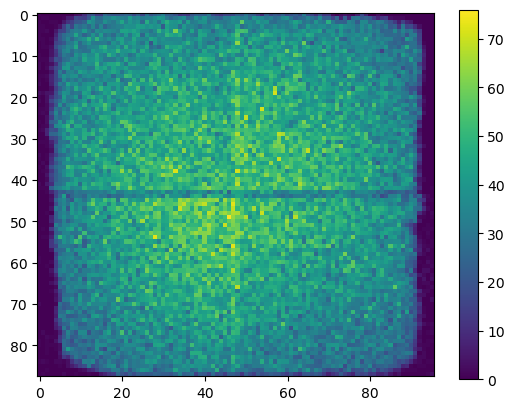

In [12]:
# Get a sample frame; 
frame=4
plt.imshow(mossbauer.convert_image(det.get_img(frame)))
plt.colorbar()
plt.show()

## Config Files

In [14]:
# Find the related config files; 
find_calib_files_for_datafile(files[0])

{'data_file': '/data/share/data_20260312_232738.dat.8',
 'first_frame_time': datetime.datetime(2026, 3, 13, 6, 27, 53, 700104),
 'dark': '/data/dark/dark/dark_2D_1773406800.npy',
 'filter1': '/data/dark/filter/filter_1772533844.npy',
 'gain': '/data/gain/gain/gain_1773397566.npy',
 'filter2': '/data/gain/filter/filter_1773397566.npy'}

In [16]:
gain_file= find_calib_files_for_datafile(files[0])['gain']
gain = np.load(gain_file)

Text(0.5, 1.0, 'gain')

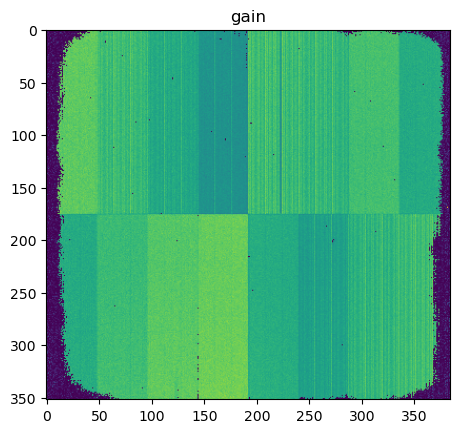

In [20]:
plt.imshow(epix.convert_image(gain))
plt.title("gain")

## Related Files

In [8]:
sfiles=find_files_in_range('/data/S2',start,end)

In [9]:
sdet= L2SpectrumDriver(sfiles[0])

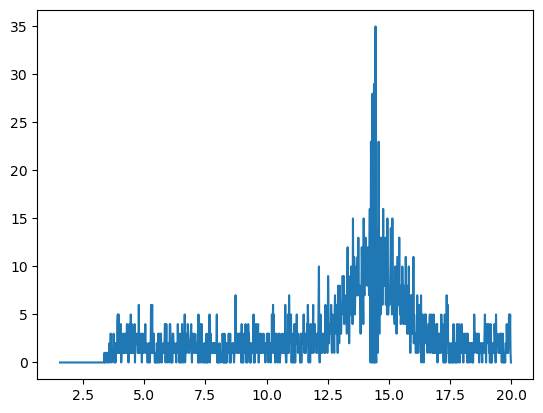

In [13]:
(energy,counts) = sdet.get_small_spec(frame)
plt.plot(energy[100:],counts[100:])

## SQL

In [22]:
sql=sql_writer()

In [25]:
times, values= get_values_in_timerange(sql, start, end, value_col="T")

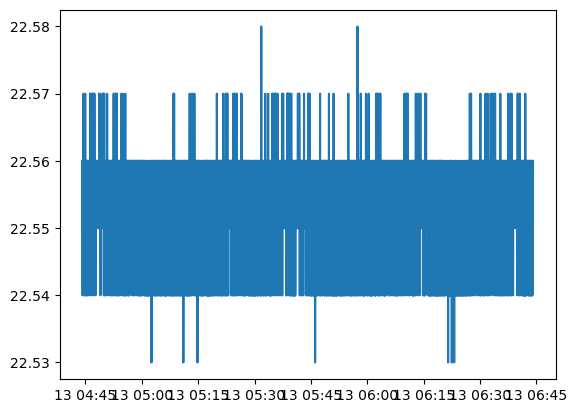

In [26]:
plt.plot(times,values)